# Load Images and Segmentation from Zarr

In [1]:
from pathlib import Path

import dask.array as da
import napari
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


In [5]:
root_dir = Path('/mnt/OPERA3/Nathan/Z_stack_tests/zarr')
row = col = 3

In [6]:
store = root_dir / f"({row},{col}).zarr"

# Avoid consolidated metadata while writer may still be running
images  = da.from_zarr(str(store / "images/0"),    consolidated=False)
masks = da.from_zarr(str(store / "labels/masks"), consolidated=False)

In [7]:
print("Images shape:", images.shape, "dtype:", images.dtype)   # (T,C,Z,Y,X)
print("Masks  shape:", masks.shape, "dtype:", masks.dtype) # (T,Z,Y,X)


Images shape: (97, 2, 25, 7992, 7992) dtype: uint16
Masks  shape: (97, 25, 7992, 7992) dtype: uint16


In [8]:
images

dask.array<from-zarr, shape=(97, 2, 25, 7992, 7992), dtype=uint16, chunksize=(1, 1, 16, 512, 512), chunktype=numpy.ndarray>

In [9]:
masks

dask.array<from-zarr, shape=(97, 25, 7992, 7992), dtype=uint16, chunksize=(1, 16, 512, 512), chunktype=numpy.ndarray>

# Tracking on compressed 2D dataset

Attempting tracking on 3D full dataset impossible due to memory constraints, so just selecting mid-slice

In [11]:
import torch
from trackastra.model import Trackastra
from trackastra.tracking import graph_to_ctc, graph_to_napari_tracks

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load a pretrained model
tracking_model = Trackastra.from_pretrained("ctc", device=device)

/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
INFO:trackastra.model.model:Loading model state from /home/dayn/.trackastra/.models/ctc/model.pt


/home/dayn/.trackastra/.models/ctc already downloaded, skipping.


/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/trackastra/model/model.py:498: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(fpath, map_l

In [10]:
# Pre-allocate NumPy arrays
T, C, Z, Y, X = images.shape
loaded_images = np.zeros((T, Y, X), dtype=images.dtype)
loaded_masks  = np.zeros((T, Y, X), dtype=masks.dtype)

T = 10

# Iterate per timepoint
for t in tqdm(range(T), desc="Loading image projections"):
    # projection of last channel across Z
    loaded_images[t] = images[t, -1, int(Z/2)].compute() #.max(axis=0)

for t in tqdm(range(T), desc="Loading mask slices"):
    # take z=12 from masks
    loaded_masks[t]  = masks[t, int(Z/2)].compute()


Loading image projections:   0%|          | 0/10 [00:00<?, ?it/s]

Loading mask slices:   0%|          | 0/10 [00:00<?, ?it/s]

In [14]:
loaded_images.shape, loaded_masks.shape

((97, 7992, 7992), (97, 7992, 7992))

In [16]:
loaded_images[:T].shape

(10, 7992, 7992)

In [17]:
%%time
# # Track the cells
track_graph = tracking_model.track(loaded_images[:T], loaded_masks[:T], mode="greedy_nodiv")  # or mode="ilp", or "greedy_nodiv"

# Write to cell tracking challenge format
ctc_tracks, masks_tracked = graph_to_ctc(
      track_graph,
      loaded_masks,
      outdir=None,
)

INFO:trackastra.model.model_api:Predicting weights for candidate graph
INFO:trackastra.data.wrfeat:Extracting features from 10 detections
INFO:trackastra.data.wrfeat:Using single process for feature extraction
Extracting features: 100%|█████████████████████████████████████████████████████████████| 10/10 [02:12<00:00, 13.27s/it]
INFO:trackastra.model.model_api:Building windows
Building windows: 100%|████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 1935.79it/s]
INFO:trackastra.model.model_api:Predicting windows
Computing associations: 100%|████████████████████████████████████████████████████████████| 7/7 [00:07<00:00,  1.08s/it]
INFO:trackastra.model.model_api:Running greedy tracker
INFO:trackastra.tracking.tracking:Build candidate graph with delta_t=1
INFO:trackastra.tracking.tracking:Added 16703 vertices, 15470 edges                                                    
INFO:trackastra.tracking.tracking:Running greedy tracker
Converting graph to CTC res

CPU times: user 2min 54s, sys: 9.25 s, total: 3min 3s
Wall time: 3min 3s


In [18]:
napari_tracks, napari_tracks_graph, _ = graph_to_napari_tracks(track_graph)

100%|███████████████████████████████████████████████████████████████████████████| 2330/2330 [00:00<00:00, 45213.97it/s]


In [19]:
napari_tracks

array([[1.00000000e+00, 0.00000000e+00, 8.66701294e+02, 6.51110596e+03],
       [1.00000000e+00, 1.00000000e+00, 8.58797546e+02, 6.51486914e+03],
       [1.00000000e+00, 2.00000000e+00, 8.44859497e+02, 6.53206836e+03],
       ...,
       [2.32900000e+03, 9.00000000e+00, 2.80524829e+03, 6.07921094e+03],
       [2.33000000e+03, 0.00000000e+00, 1.77373242e+03, 5.41835205e+03],
       [2.33000000e+03, 1.00000000e+00, 1.70036243e+03, 5.44929150e+03]])

# Visualise

In [25]:
viewer = napari.Viewer(title = 'inspecting 3D tracking')

In [26]:
scale = (1,0.14949,0.14949)

In [27]:
viewer.add_labels(masks_tracked, scale=scale)


<Labels layer 'masks_tracked' at 0x7cb57cbf90c0>

In [29]:
viewer.add_image(loaded_images, colormap='green', scale = scale)

<Image layer 'loaded_images' at 0x7cb57cb98280>

In [28]:
viewer.add_tracks(data=napari_tracks, graph=napari_tracks_graph, scale = scale)

<Tracks layer 'napari_tracks' at 0x7cb57cbf8c10>

In [35]:
viewer.scale_bar.visible = True
viewer.scale_bar.unit = "µm"       # units displayed on bar
viewer.scale_bar.position = "bottom_right"  # other options: top_left, bottom_left, top_right
viewer.scale_bar.colored = False    # use layer colormap for scalebar color
viewer.scale_bar.length = 200
viewer.scale_bar.ticks = False
viewer.scale_bar.font_size = 20

In [36]:
def update_time(event):
    """Update time"""
    time = viewer.dims.current_step[0] / 2
    viewer.text_overlay.text = f"{time:1.1f} hours"

viewer.text_overlay.visible = True
viewer.text_overlay.color = 'white'
viewer.text_overlay.font_size = 20
viewer.text_overlay.position = 'bottom_left'
viewer.dims.events.current_step.connect(update_time)

<function __main__.update_time(event)>

Rendering frames...


100%|██████████████████████████████████████████████████████████████████████████████████| 97/97 [00:25<00:00,  3.87it/s]


# Extract tracks

In [22]:
tracks = pd.DataFrame(napari_tracks, columns=['ID', 't', 'y', 'x'])

In [23]:
tracks

,ID,t,y,x
0,1.0,0.0,866.701294,6511.105957
1,1.0,1.0,858.797546,6514.869141
2,1.0,2.0,844.859497,6532.068359
3,1.0,3.0,846.547546,6536.557617
4,1.0,4.0,841.065063,6559.479492
...,...,...,...,...
15762,2329.0,7.0,2845.401855,6132.186035
15763,2329.0,8.0,2817.837402,6083.013184
15764,2329.0,9.0,2805.248291,6079.210938
15765,2330.0,0.0,1773.732422,5418.352051


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

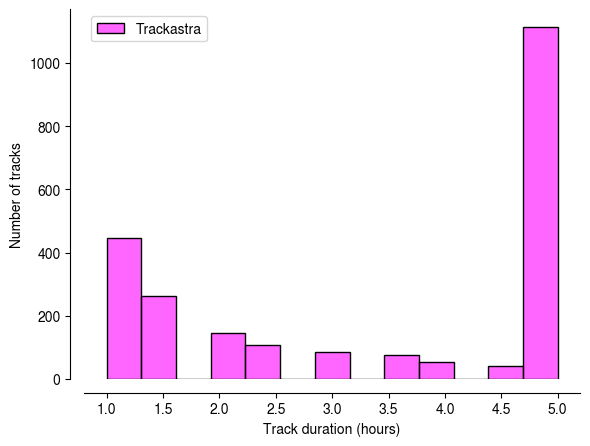

In [25]:
sns.histplot(tracks.groupby('ID').size() * 0.5, color='magenta', #bins=100,
             label='Trackastra', alpha = 0.6)
# sns.histplot(btracks.groupby('ID').size() * 0.25, color='darkgreen', bins=100, label='btrack', alpha = 0.6)
plt.legend()
plt.xlabel('Track duration (hours)')
plt.ylabel('Number of tracks')
# plt.ylim(0,100)
sns.despine(offset=10)
# plt.savefig('/mnt/DATA2/VP0001/labels/pos_15/dev/btrackastra_length_comparison.pdf', bbox_inches ='tight', dpi = 314)

In [47]:
tracks.groupby('ID').size()

ID
1.0       97
2.0        7
3.0        4
4.0        2
5.0        2
          ..
8621.0     5
8622.0     3
8623.0     3
8624.0    32
8625.0     5
Length: 8625, dtype: int64

In [51]:
N=93
counts = tracks.groupby("ID").size()
longer_than_N = counts[counts > N]
longer_than_N

ID
1.0       97
6.0       97
10.0      97
18.0      97
19.0      97
          ..
8165.0    97
8214.0    94
8295.0    97
8371.0    97
8531.0    97
Length: 501, dtype: int64

## Now measure the expression of fluorescence markers across ALL DIMENSIONS

In [42]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

In [119]:
tracks

,ID,t,y,x
0,1.0,0.0,866.701294,6511.105957
1,1.0,1.0,858.797546,6514.869141
2,1.0,2.0,844.859497,6532.068359
3,1.0,3.0,846.547546,6536.557617
4,1.0,4.0,841.065063,6559.479492
...,...,...,...,...
15762,2329.0,7.0,2845.401855,6132.186035
15763,2329.0,8.0,2817.837402,6083.013184
15764,2329.0,9.0,2805.248291,6079.210938
15765,2330.0,0.0,1773.732422,5418.352051


In [118]:
N=93
filtered_tracks = tracks[tracks.groupby("ID")["ID"].transform("size") > 8]

,ID,t,y,x
0,1.0,0.0,866.701294,6511.105957
1,1.0,1.0,858.797546,6514.869141
2,1.0,2.0,844.859497,6532.068359
3,1.0,3.0,846.547546,6536.557617
4,1.0,4.0,841.065063,6559.479492
...,...,...,...,...
15757,2328.0,5.0,3436.347900,7818.551270
15758,2328.0,6.0,3421.790527,7843.799805
15759,2328.0,7.0,3423.467041,7839.421387
15760,2328.0,8.0,3396.131836,7853.890137


In [121]:
filtered_tracks

,ID,t,y,x
0,1.0,0.0,866.701294,6511.105957
1,1.0,1.0,858.797546,6514.869141
2,1.0,2.0,844.859497,6532.068359
3,1.0,3.0,846.547546,6536.557617
4,1.0,4.0,841.065063,6559.479492
...,...,...,...,...
15757,2328.0,5.0,3436.347900,7818.551270
15758,2328.0,6.0,3421.790527,7843.799805
15759,2328.0,7.0,3423.467041,7839.421387
15760,2328.0,8.0,3396.131836,7853.890137


In [123]:
L

5

In [136]:


threshold = 200  # threshold for MTB in channel 0


L=T//2
filtered_tracks = tracks[tracks.groupby("ID")["ID"].transform("size") > L]

quantified_tracks = []

for t in tqdm(range(T), desc="iterating over timepoints"):
    # isolate all the tracks at t
    tracks_at_t = filtered_tracks[filtered_tracks['t']==t]
    # safety check
    if tracks_at_t.empty:
        continue
    # load mtb image 
    mtb_frame = images[t,0].compute()
    # load segmentation
    masks_frame = masks[t].compute()
    # pre-threshold once per timepoint
    mtb_mask_t = mtb_frame >= threshold
    # iterate over the individual tracks at t 
    for i, row in tqdm(tracks_at_t.iterrows(), desc = 'iterating over tracks', total = len(tracks_at_t)):
        # extract the track_ID, y and x coord  
        track_ID = int(row['ID'])
        y = int(row['y'])
        x = int(row['x'])
        # isolate the segment ID at the 12th z slice (which was used for tracking)
        segment_ID = masks_frame[Z//2, y, x]
        # use this segment ID to iterate over Z
        for z in tqdm(range(masks_frame.shape[0]), desc='iterating over z slices', leave=False):
            # get single z_slice of masks
            seg_z = masks_frame[z]  
            # check if this segment is in this z slice
            present = (seg_z == segment_ID)
            if not present.any():
                continue
            
            cell_area_px = int(present.sum())
            mtb_area_px  = int((present & mtb_mask_t[z]).sum())

            quantified_tracks.append({
                "t": t,
                "ID": track_ID,
                "z": z,
                "y": y,
                "x": x,
                "cell_area_px": cell_area_px,
                "mtb_area_px": mtb_area_px,
                "segment_ID": segment_ID,

            })

quantified_tracks = pd.DataFrame.from_records(quantified_tracks)



iterating over timepoints:   0%|          | 0/10 [00:00<?, ?it/s]

iterating over tracks:   0%|          | 0/1253 [00:00<?, ?it/s]

iterating over z slices:   0%|          | 0/25 [00:00<?, ?it/s]

iterating over z slices:   0%|          | 0/25 [00:00<?, ?it/s]

iterating over z slices:   0%|          | 0/25 [00:00<?, ?it/s]

...

iterating over z slices:   0%|          | 0/25 [00:00<?, ?it/s]

iterating over z slices:   0%|          | 0/25 [00:00<?, ?it/s]

iterating over z slices:   0%|          | 0/25 [00:00<?, ?it/s]

iterating over z slices:   0%|          | 0/25 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [137]:

quantified_tracks = pd.DataFrame.from_records(quantified_tracks)



In [140]:
viewer.add_image(masks_frame==1209)

<Image layer 'Image [3]' at 0x7368d2380d30>

In [143]:
(masks_frame[4]==1209).sum()

14650

In [147]:
(mtb_mask_t[4]*(masks_frame[4]==1209)).sum()

166

In [139]:

quantified_tracks[quantified_tracks['mtb_area_px'] >0]

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID
55,0,4,4,4652,4568,14650,166,1209
56,0,4,5,4652,4568,9500,481,1209
57,0,4,6,4652,4568,9650,1017,1209
58,0,4,7,4652,4568,9250,1159,1209
59,0,4,8,4652,4568,9525,1247,1209
60,0,4,9,4652,4568,10350,1201,1209
61,0,4,10,4652,4568,10125,877,1209
62,0,4,11,4652,4568,9875,668,1209
63,0,4,12,4652,4568,9725,468,1209
64,0,4,13,4652,4568,9575,349,1209


# Iterate over all positions, tracking and quantifying

In [2]:

from pathlib import Path

import anndata as ad
import dask.array as da
import napari
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from trackastra.model import Trackastra
from trackastra.tracking import graph_to_ctc, graph_to_napari_tracks

device = "cuda" if torch.cuda.is_available() else "cpu"
# Load a pretrained model
tracking_model = Trackastra.from_pretrained("ctc", device=device)

INFO:trackastra.model.model:Loading model state from /home/dayn/.trackastra/.models/ctc/model.pt


/home/dayn/.trackastra/.models/ctc already downloaded, skipping.


INFO:trackastra.model.model_api:Using device cuda


In [5]:
# --- RUN ONLY QUANTIFICATION FOR (3,3) ---

from pathlib import Path

import dask.array as da
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

root_dir = Path('/mnt/OPERA3/Nathan/Z_stack_tests/zarr')
rc_row, rc_col = 3, 3
rc_stem = f"({rc_row},{rc_col})"
store = root_dir / f"{rc_stem}.zarr"
assert store.exists(), f"Missing store: {store}"

# Load dask arrays (T,C,Z,Y,X) and (T,Z,Y,X)
images = da.from_zarr(str(store / "images" / "0"), consolidated=False)
masks  = da.from_zarr(str(store / "labels" / "masks"), consolidated=False)
T, C, Z, Y, X = images.shape

# --- load previously saved tracks (skip tracking entirely) ---
tracks_csv = root_dir / f"{rc_stem}_tracks.csv"
if tracks_csv.exists():
    tracks = pd.read_csv(tracks_csv)
else:
    # fallback to AnnData if CSV not present
    tables_tracks = store / "tables" / "tracks"
    adata = ad.read_zarr(str(tables_tracks))
    tracks = adata.obs.reset_index(drop=True)

# Ensure dtypes expected downstream
tracks = tracks.astype({"ID":"int64","t":"int64","y":"int32","x":"int32"})
if "row" not in tracks.columns: tracks["row"] = rc_row
if "col" not in tracks.columns: tracks["col"] = rc_col

# --- filter sufficiently long tracks ---
L = T // 2
filtered_tracks = tracks[tracks.groupby("ID")["ID"].transform("size") > L]

# --- quantification params ---
threshold = 200  # channel 0 MTB threshold

quantified_rows = []
for t in tqdm(range(T), desc=f"[{rc_stem}] quantify per-Z"):
    t_rows = filtered_tracks[filtered_tracks["t"] == t]
    if t_rows.empty:
        continue

    # Pull full (Z,Y,X) for this frame once
    mtb_frame   = images[t, 0].compute()   # ch 0
    masks_frame = masks[t].compute()       # segments
    mtb_mask_t  = mtb_frame >= threshold   # boolean (Z,Y,X)

    # Row-wise over current detections
    for _, det in tqdm(t_rows.iterrows(), total=len(t_rows), leave=False):
        track_id = int(det.ID)
        y = int(det.y); x = int(det.x)

        # Identify segment on mid-Z first; skip if background
        seg_id = int(masks_frame[Z // 2, y, x])
        if seg_id == 0:
            continue

        # Accumulate per-Z areas
        for z in range(Z):
            present = (masks_frame[z] == seg_id)
            if not present.any():
                continue  # segment absent on this slice

            cell_area_px = int(present.sum())
            mtb_area_px  = int((present & mtb_mask_t[z]).sum())

            quantified_rows.append({
                "t": t, "ID": track_id, "z": z, "y": y, "x": x,
                "cell_area_px": cell_area_px,
                "mtb_area_px": mtb_area_px,
                "segment_ID": seg_id,
            })

# --- finalize and write outputs ---
quantified_tracks = pd.DataFrame.from_records(quantified_rows)
if not quantified_tracks.empty:
    quantified_tracks["row"] = rc_row
    quantified_tracks["col"] = rc_col
    quantified_tracks = quantified_tracks.astype({
        "ID":"int64","t":"int64","z":"int32","y":"int32","x":"int32",
        "cell_area_px":"int32","mtb_area_px":"int32","segment_ID":"int64",
        "row":"int16","col":"int16",
    })

    # CSV
    (root_dir / f"{rc_stem}_quantified_tracks.csv").write_text(
        quantified_tracks.to_csv(index=False)
    )

    # AnnData
    tables_qt = store / "tables" / "quantified_tracks"
    tables_qt.mkdir(parents=True, exist_ok=True)
    ad.AnnData(X=None, obs=quantified_tracks.reset_index(drop=True)).write_zarr(str(tables_qt))
else:
    print(f"[{rc_stem}] No quantified rows produced (empty after filtering or no segments found).")


[(3,3)] quantify per-Z:   0%|          | 0/97 [00:00<?, ?it/s]

  0%|          | 0/809 [00:00<?, ?it/s]

  0%|          | 0/817 [00:00<?, ?it/s]

  0%|          | 0/825 [00:00<?, ?it/s]

  0%|          | 0/834 [00:00<?, ?it/s]

...

  0%|          | 0/850 [00:00<?, ?it/s]

  0%|          | 0/840 [00:00<?, ?it/s]

  0%|          | 0/831 [00:00<?, ?it/s]

  0%|          | 0/820 [00:00<?, ?it/s]

/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [ ]:
root_dir = Path('/mnt/OPERA3/Nathan/Z_stack_tests/zarr')

# iterate stores named like "(row,col).zarr"
for store in sorted(root_dir.glob("(*,*).zarr")):
    # parse "(r,c)" safely
    r_str, c_str = store.stem.strip("()").split(",")
    rc_row, rc_col = int(r_str), int(c_str)
    rc_stem = store.stem

    # skip (3, 3)
    if (rc_row, rc_col) == (3, 3):
        continue
        
    # dask loaders (avoid consolidated while writing elsewhere)
    images = da.from_zarr(str(store / "images/0"), consolidated=False)     # (T,C,Z,Y,X)
    masks  = da.from_zarr(str(store / "labels/masks"), consolidated=False) # (T,Z,Y,X)

    # mid-Z slice for 2D tracking
    T, C, Z, Y, X = images.shape
    loaded_images = np.zeros((T, Y, X), dtype=images.dtype)
    loaded_masks  = np.zeros((T, Y, X), dtype=masks.dtype)

    for t in tqdm(range(T), desc=f"[{rc_stem}] load mid-Z images"):
        loaded_images[t] = images[t, -1, Z//2].compute()   # last channel, mid-Z
    for t in tqdm(range(T), desc=f"[{rc_stem}] load mid-Z masks"):
        loaded_masks[t]  = masks[t, Z//2].compute()

    # --- tracking (assumes tracking_model / graph_to_* already defined) ---
    track_graph = tracking_model.track(loaded_images, loaded_masks, mode="greedy_nodiv")
    ctc_tracks, masks_tracked = graph_to_ctc(track_graph, loaded_masks, outdir=None)
    napari_tracks, napari_tracks_graph, _ = graph_to_napari_tracks(track_graph)

    tracks = pd.DataFrame(napari_tracks, columns=['ID', 't', 'y', 'x'])
    tracks['row'] = rc_row
    tracks['col'] = rc_col
    tracks = tracks.astype({"ID":"int64","t":"int64","y":"int32","x":"int32","row":"int16","col":"int16"})

    # save tracks
    (root_dir / f"{rc_stem}_tracks.csv").write_text(tracks.to_csv(index=False))
    tables_tracks = store / "tables" / "tracks"
    tables_tracks.mkdir(parents=True, exist_ok=True)
    ad.AnnData(X=None, obs=tracks.reset_index(drop=True)).write_zarr(str(tables_tracks))

    # --- per-Z MTB quantification for sufficiently long tracks ---
    threshold = 200
    L = T // 2
    filtered_tracks = tracks[tracks.groupby("ID")["ID"].transform("size") > L]

    quantified_rows = []
    for t in tqdm(range(T), desc=f"[{rc_stem}] quantify per-Z"):
        t_rows = filtered_tracks[filtered_tracks['t'] == t]
        if t_rows.empty:
            continue

        mtb_frame   = images[t, 0].compute()   # (Z,Y,X) channel 0
        masks_frame = masks[t].compute()       # (Z,Y,X)
        mtb_mask_t  = mtb_frame >= threshold

        for _, det in tqdm(t_rows.iterrows(), total=len(t_rows), leave=False):
            track_id = int(det.ID)
            y = int(det.y)
            x = int(det.x)

            seg_id = int(masks_frame[Z//2, y, x])
            if seg_id == 0:
                continue

            for z in range(Z):
                present = (masks_frame[z] == seg_id)
                if not present.any():
                    continue

                cell_area_px = int(present.sum())
                mtb_area_px  = int((present & mtb_mask_t[z]).sum())

                quantified_rows.append({
                    "t": t, "ID": track_id, "z": z, "y": y, "x": x,
                    "cell_area_px": cell_area_px,
                    "mtb_area_px": mtb_area_px,
                    "segment_ID": seg_id,
                })

    quantified_tracks = pd.DataFrame.from_records(quantified_rows)
    if not quantified_tracks.empty:
        quantified_tracks["row"] = rc_row
        quantified_tracks["col"] = rc_col
        quantified_tracks = quantified_tracks.astype({
            "ID":"int64","t":"int64","z":"int32","y":"int32","x":"int32",
            "cell_area_px":"int32","mtb_area_px":"int32","segment_ID":"int64",
            "row":"int16","col":"int16",
        })

        # save quantified tracks
        (root_dir / f"{rc_stem}_quantified_tracks.csv").write_text(
            quantified_tracks.to_csv(index=False)
        )
        tables_qt = store / "tables" / "quantified_tracks"
        tables_qt.mkdir(parents=True, exist_ok=True)
        ad.AnnData(X=None, obs=quantified_tracks.reset_index(drop=True)).write_zarr(str(tables_qt))


/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/zarr/creation.py:250: UserWarning: ignoring keyword argument 'read_only'
  warn('ignoring keyword argument %r' % k)
/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/zarr/creation.py:250: UserWarning: ignoring keyword argument 'consolidated'
  warn('ignoring keyword argument %r' % k)


[(3,4)] load mid-Z images:   0%|          | 0/97 [00:00<?, ?it/s]

[(3,4)] load mid-Z masks:   0%|          | 0/97 [00:00<?, ?it/s]

INFO:trackastra.model.model_api:Predicting weights for candidate graph
INFO:trackastra.data.wrfeat:Extracting features from 97 detections
INFO:trackastra.data.wrfeat:Using single process for feature extraction
Extracting features: 100%|██████████████████████| 97/97 [25:02<00:00, 15.49s/it]
INFO:trackastra.model.model_api:Building windows
Building windows: 100%|███████████████████████| 94/94 [00:00<00:00, 2400.22it/s]
INFO:trackastra.model.model_api:Predicting windows
Computing associations: 100%|███████████████████| 94/94 [02:48<00:00,  1.79s/it]
INFO:trackastra.model.model_api:Running greedy tracker
INFO:trackastra.tracking.tracking:Build candidate graph with delta_t=1
INFO:trackastra.tracking.tracking:Added 181024 vertices, 188161 edges           
INFO:trackastra.tracking.tracking:Running greedy tracker
100%|█████████████████████████████████████| 7964/7964 [00:01<00:00, 6893.67it/s]
/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: Impli

[(3,4)] quantify per-Z:   0%|          | 0/97 [00:00<?, ?it/s]

...

  0%|          | 0/886 [00:00<?, ?it/s]

  0%|          | 0/908 [00:00<?, ?it/s]

  0%|          | 0/921 [00:00<?, ?it/s]

  0%|          | 0/933 [00:00<?, ?it/s]

  0%|          | 0/947 [00:00<?, ?it/s]